In [1]:
import time
from SSO import SSO

In [2]:
# 設定初始解 >> >> 詳細說明請看'自訂初始化參數'
params = {
    'x1': 0,
    'x2': 2,
    'x3': 5,
    'x4': 2,
    'x5': 0.3,
    'x6': 1,
    'x8': 8,
}

# 設定要搜索的變數 & 範圍  >> 詳細說明請看'搜索範圍設定'
params_range = {
    'x1': (-10.0, 10.0),
    'x2': (-125, 135),
    'x3': (-500, 500),
    'x4': [1, 2, 5],
    'x5': (-0.12, 1.38)
}

# 不用動
def get_param(X, keys=params_range.keys(), params=params):
    """
    Update `param` dictionary based on `keys` and corresponding values from `X`.

    Parameters:
        X (numpy.ndarray): Array of parameter values corresponding to the keys.
        keys (list): List of parameter names (keys) used to map values in X.
        params_range (dict): Search range for each parameter, where values can be
                             tuples (for range) or lists (for discrete options).

    Returns:
        dict: Updated `param` dictionary with values from `X`, converting to int if needed.
    """
    # 創建 `param` 的拷貝，避免修改原始字典
    param = params.copy()

    # 根據 keys 中的索引更新 param 中對應的鍵
    for i, key in enumerate(keys):
        # 判斷該參數是否需要轉換為整數
        boundary = params_range[key]
        if (
            isinstance(boundary, tuple) and all(isinstance(b, int) for b in boundary)
        ) or (
            isinstance(boundary, list) and all(isinstance(b, int) for b in boundary)
        ):
            # 如果是整數範圍或整數列表，將值轉換為整數
            param[key] = int(X[i])
        else:
            # 否則保留原類型
            param[key] = X[i]

    return param

# 適應度函數(自訂義)
def fitness(X, params_range=params_range, params=params):
    """
    Fitness function

    Parameters:
        X (numpy.ndarray): Array of parameter values for the model.
                           The array is expected to be a 1D array where each element corresponds 
                           to a specific parameter defined in `params_range.keys()`.

                           Example:
                           X = [best_weight_decay_1, best_lamda, best_al, best_earlystop, ...]

    Returns:
        fitness_value (float): Calculated fitness value based on the parameter values in X.
        record_message (dict): Dictionary containing the following metrics:
                               - 'val_acc' (float): Validation accuracy (fitness value).
                               - 'test_acc' (float): Test accuracy.
                               - 'train_time' (float): Time taken to compute the fitness value.
    """
    # 這個可以不用動，改下面就好了。
    param = get_param(keys=params_range.keys(), params=params, X=X)
    

    # ---------------從這邊開始改---------------
    start_time = time.time()
    
    fitness_value = ((int(param['x6']) + param['x1'] + int(param['x2']) * param['x5']) - int(param['x3'])) + int(param['x8'])/ int(param['x4'])
    
    test_acc = ((int(param['x6']) + param['x1'] + int(param['x2']) * param['x5']) - int(param['x3'])) + int(param['x8']) / int(param['x4']) /10
    train_time = time.time() - start_time
    # train_time 也可以從自定義的腳本獲取，這個夾法會記錄到檔案寫入時間，比較不建議

    # 可按需求存資訊
    # Record message 建議使用字典，以便索引
    record_message = {
                    'val_acc': fitness_value,
                    'test_acc': test_acc,
                    'train_time':train_time,            
                }
    
    return fitness_value, record_message

In [3]:
sso_searcher = SSO(Ngen=10,                 # 世代數
    Nsol=5,                                 # 解的數量
    Cg=0.4,                                 # 全局最佳解的權重
    Cp=0.7,                                 # 個體最佳解的權重
    Cw=0.9,                                 # 隨機解的權重
    save_name='test',                       # 記錄檔儲存前綴
    fitness=fitness,                        # 適應度函數
    base_param=params,                      # 基礎參數 (可選)
    boundary=params_range,                  # 支持 tuple 或 list (詳細說明請參照前述)
    direction="minimize",                   # 優化方向 ('maximize', 'minimize')
    )


In [4]:
sso_searcher.run()

Created a new log file: sso_checkpoint/log.pkl
[ Thu Feb 20 12:29:02 2025 ] Gen :   0 | Sol :   0 | fitness :             0.600000 | search_time :             0.000000 | params : (0.0, 2.0, 5.0, 2.0, 0.3) | record_message : {'val_acc': 0.6000000000000001, 'test_acc': -3.0, 'train_time': 0.0}
[ Thu Feb 20 12:29:02 2025 ] Gen :   0 | Sol :   1 | fitness :          -359.143373 | search_time :             0.000000 | params : (7.029519180842151, 37.0, 395.0, 2.0, 0.6439758818747655) | record_message : {'val_acc': -359.14337318979153, 'test_acc': -362.74337318979155, 'train_time': 0.0}
[ Thu Feb 20 12:29:02 2025 ] Gen :   0 | Sol :   2 | fitness :          -555.514364 | search_time :             0.000000 | params : (-1.7861195020938148, -93.0, 457.0, 1.0, 1.1368628417749393) | record_message : {'val_acc': -555.5143637871631, 'test_acc': -562.7143637871632, 'train_time': 0.0}
[ Thu Feb 20 12:29:02 2025 ] Gen :   0 | Sol :   3 | fitness :           226.197208 | search_time :             0.0000

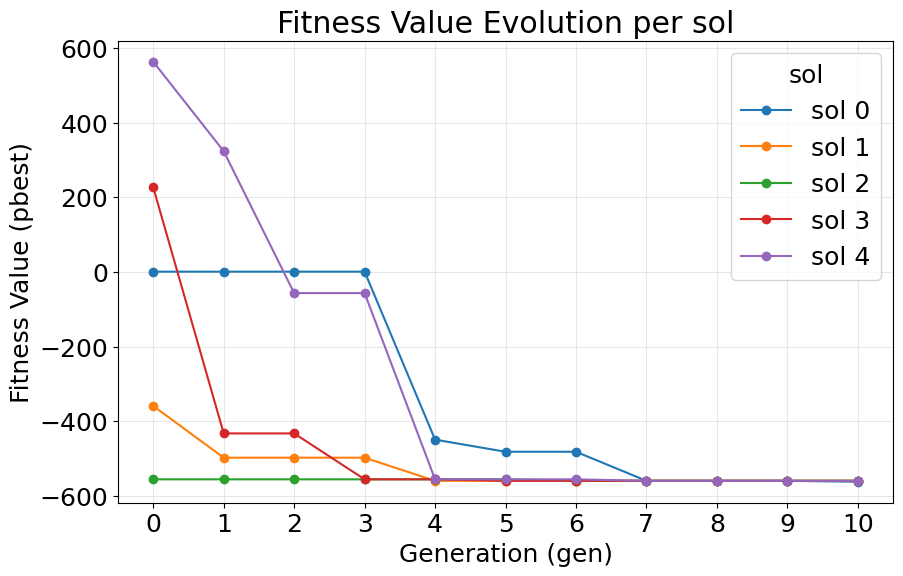

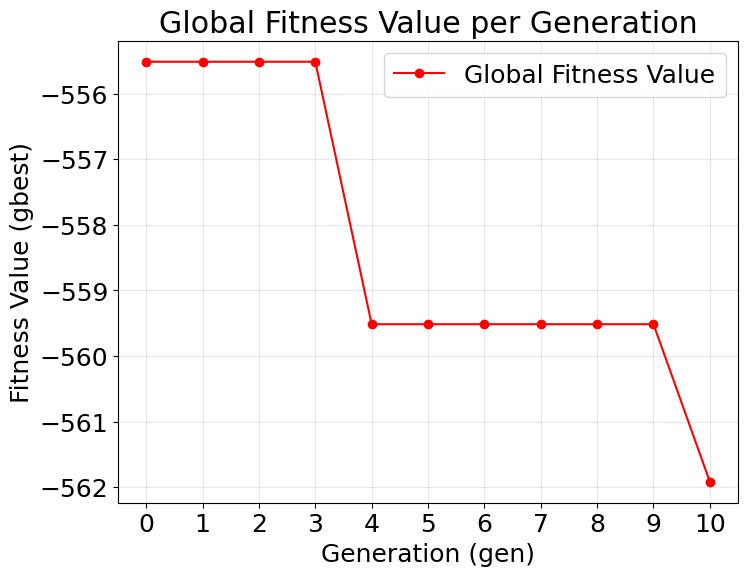

In [5]:
sso_searcher.plot()

# Resume Run 接續功能

## 1. 重新開啟一個SSO
## 2. 在sso_checkpoint處，會有一個log.pkl，把它放進去即可。
log.pkl 是 SSO 運行時每次update都會更新的紀錄檔，儲存資料格式與result一致。(與之前儲存有稍微不同，有改版過)
如果SSO運行完畢，SSO就會把這個log.pkl清除，並且寫一個result進去sso_result資料夾。


In [7]:
sso_resume_searcher = SSO(Ngen=50,                 # 世代數
    Nsol=5,                                 # 解的數量
    Cg=0.4,                                 # 全局最佳解的權重
    Cp=0.7,                                 # 個體最佳解的權重
    Cw=0.9,                                 # 隨機解的權重
    save_name='test',                       # 記錄檔儲存前綴
    fitness=fitness,                        # 適應度函數
    base_param=params,                      # 基礎參數 (可選)
    boundary=params_range,                  # 支持 tuple 或 list (詳細說明請參照前述)
    direction="minimize",                   # 優化方向 ('maximize', 'minimize')
    )

sso_resume_searcher.resume_run(r'sso_checkpoint\log.pkl')

🔄 Resume Optimization on Gen: 11 | sol: 0
[ Thu Feb 20 12:29:22 2025 ] Gen :  11 | Sol :   0 | fitness :          -578.425788 | search_time :             0.002581 | params : (-9.194425423716552, -115.0, 415.0, 5.0, 1.363750982502237) | record_message : {'val_acc': -578.4257884114737, 'test_acc': -579.8657884114738, 'train_time': 0.0}
[ Thu Feb 20 12:29:22 2025 ] Gen :  11 | Sol :   1 | fitness :          -390.338138 | search_time :             0.002581 | params : (-9.194425423716552, 27.0, 415.0, 5.0, 1.1576402832187411) | record_message : {'val_acc': -390.3381377768105, 'test_acc': -391.7781377768105, 'train_time': 0.0}
[ Thu Feb 20 12:29:22 2025 ] Gen :  11 | Sol :   2 | fitness :          -578.425788 | search_time :             0.002581 | params : (-9.194425423716552, -115.0, 415.0, 5.0, 1.363750982502237) | record_message : {'val_acc': -578.4257884114737, 'test_acc': -579.8657884114738, 'train_time': 0.0}
[ Thu Feb 20 12:29:22 2025 ] Gen :  11 | Sol :   3 | fitness :          -578.

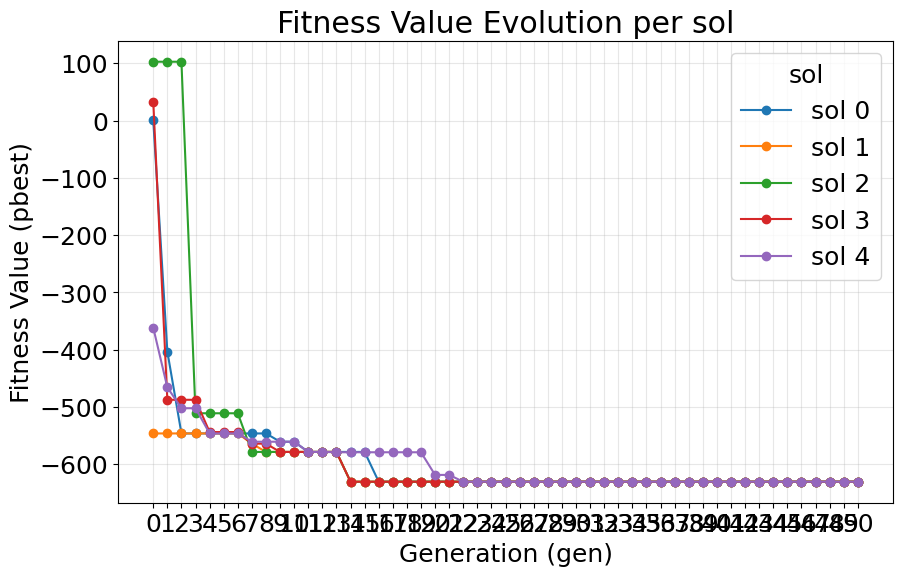

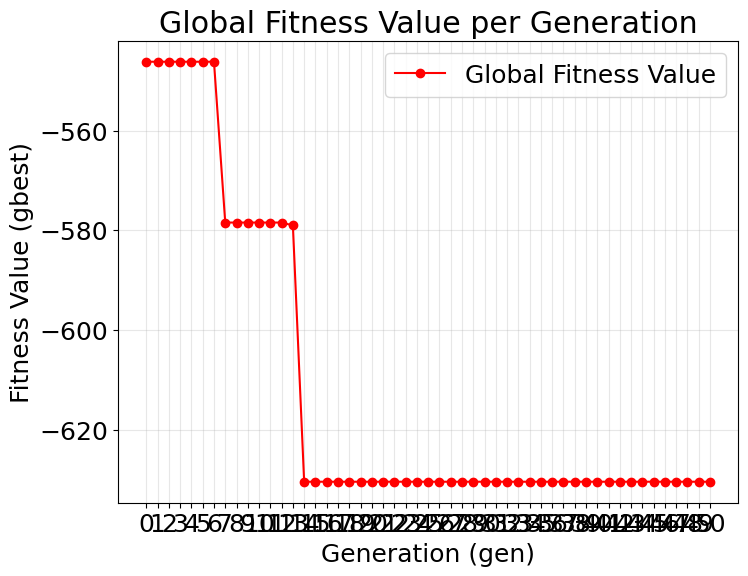

: 

In [ ]:
sso_resume_searcher.plot()

In [2]:
from SSO import SSO

sso_resume_searcher = SSO(Ngen=50,          # 世代數
    Nsol=5,                                 # 解的數量
    Cg=0.4,                                 # 全局最佳解的權重
    Cp=0.7,                                 # 個體最佳解的權重
    Cw=0.9,                                 # 隨機解的權重
    save_name='test',                       # 記錄檔儲存前綴
    fitness=fitness,                        # 適應度函數
    base_param=params,                      # 基礎參數 (可選)
    boundary=params_range,                  # 支持 tuple 或 list (詳細說明請參照前述)
    direction="minimize",                   # 優化方向 ('maximize', 'minimize')
    )

sso_resume_searcher.load_result(r'sso_result\test_ggen10_gsol4_searchtime0.050069332122802734_b4cf26bb-2b2e-4a71-8dde-ef5b15e68a57.pkl')


🔄 Loading from saved checkpoint...
📂 File ggen: 10, gsol: 4
📝 Record Information
🔍 Record Message: {'val_acc': -597.0428828004741, 'test_acc': -598.4828828004742, 'train_time': 0.0}
🔧 Parameters: [  -8.70221749 -123.          476.            5.            0.93447695]
🏆 Fitness: -597.0428828004741
